# 📘 Customer Purchase Propensity — Data Cleaning & Feature Engineering Pipeline


🎯 **Project Overview:** As a Junior Data Analyst at an e-commerce company, this
notebook cleans, preprocesses and engineers features from multiple raw data sources (CSV, JSON, SQL, API) to
prepare a dataset for a future ML model predicting whether a customer will make a purchase
(`purchased` = 1 or 0). No model is trained here — the focus is entirely on the
**Data Preprocessing and Feature Engineering pipeline**.


## 🧠 Step 1 — Project Planning & Problem Framing


#### 📌 What is Data Analysis?

Data Analysis is the process of inspecting, cleaning and modeling data to extract useful information and support decisions. Here it means understanding customer, transaction and product data well enough to know what's missing, what's messy, and what's predictive of a purchase.


#### 📌 Steps in a Data Science Project

(1) Understand the business problem; (2) Acquire data from all relevant sources; (3) Explore and clean the data (EDA + preprocessing); (4) Engineer features; (5) Train and evaluate a model; (6) Deploy and monitor. This notebook focuses on steps 2–4, which is typically 70-80% of real project effort.


#### 📌 Framing This as a Machine Learning Problem

This is a **binary classification** problem: predict `purchased`
(1 = will purchase, 0 = will not) using customer demographics (age, income, education), behavioral signals
(total_purchases, satisfaction_level, loyalty_points) and product context (category, price). The target is
imbalanced-ish, so evaluation would ultimately use metrics like ROC-AUC or F1 rather than accuracy alone —
though model training itself is out of scope for this project.


## 🌐 Step 2 — Data Import & Understanding


### 📄 Load CSV — Customer Demographics


#### 🟦 Code Implementation

Python execution block for this step.


In [1]:
import pandas as pd
import numpy as np

df_customers = pd.read_csv("customers.csv")
print("Customers shape:", df_customers.shape)
df_customers.head()

Customers shape: (600, 7)


,customer_id,age,gender,region,income,education_level,signup_date
0,CUST-0001,NaN,Male,South,47536.17,Primary,2019-06-09
1,CUST-0002,33.0,Male,North,77221.25,Secondary,2021-05-03
2,CUST-0003,22.0,Male,South,NaN,Secondary,2021-08-31
3,CUST-0004,53.0,Male,South,54174.65,Graduate,2020-12-28
4,CUST-0005,52.0,Female,East,81447.74,Secondary,2024-02-06


#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Load customer demographic data (IDs, age, gender, region, income, education, signup date) from a CSV file.


🧬 **Column(s) Used:** `customer_id, age, gender, region, income, education_level, signup_date`


📊 **Result:** 600 customer records loaded with 7 columns.


🧠 **Intuition:** This is the core demographic table — every other source will be merged onto it using customer_id.


### 🧾 Parse JSON — Transaction Records


#### 🟦 Code Implementation

Python execution block for this step.


In [2]:
import json

with open("transactions.json") as f:
    transaction_records = json.load(f)

df_transactions = pd.DataFrame(transaction_records)
print("Transactions shape:", df_transactions.shape)
df_transactions.head()

Transactions shape: (600, 6)


,customer_id,product_id,total_purchases,last_purchase_date,satisfaction_level,purchased
0,CUST-0001,PROD021,6,2023-04-30,Low,1
1,CUST-0002,PROD034,5,2024-08-04,Medium,1
2,CUST-0003,PROD015,5,2024-07-15,Medium,1
3,CUST-0004,PROD038,3,2023-07-04,Medium,0
4,CUST-0005,PROD017,3,2024-09-03,Medium,0


#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Load transaction-level records (purchase counts, satisfaction, purchase target) from a JSON file.


🧬 **Column(s) Used:** `customer_id, product_id, total_purchases, last_purchase_date, satisfaction_level, purchased`


📊 **Result:** 600 transaction records parsed, one per customer, including the target column purchased.


🧠 **Intuition:** The target variable and key behavioral features live here, so this JSON source is central to the eventual ML problem.


### 🗄️ Import from SQL — Product Info Table


#### 🟦 Code Implementation

Python execution block for this step.


In [3]:
import sqlite3

conn = sqlite3.connect("products.db")
df_products = pd.read_sql("SELECT * FROM products", conn)
conn.close()

print("Products shape:", df_products.shape)
df_products.head()

Products shape: (40, 3)


,product_id,product_category,price
0,PROD001,Grocery,161.88
1,PROD002,Electronics,29.54
2,PROD003,Electronics,150.19
3,PROD004,Grocery,119.86
4,PROD005,Clothing,53.54


#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Connect to a SQLite database (simulating the products.sql table) and load the product catalog.


🧬 **Column(s) Used:** `product_id, product_category, price`


📊 **Result:** 40 product records loaded via SQL, each with a category and price (including a few injected price outliers).


🧠 **Intuition:** Product-level price/category context lets us understand what each customer was purchasing, which is useful signal for propensity.


### 🌍 Fetch from API — Additional User Details


#### 🟦 Code Implementation

Python execution block for this step.


In [4]:
with open("dummy_api.json") as f:
    api_users = json.load(f)

df_api = pd.DataFrame(api_users)
print("API users shape:", df_api.shape)
df_api.head()

API users shape: (600, 3)


,customer_id,membership_tier,loyalty_points
0,CUST-0001,Gold,1591
1,CUST-0002,Silver,4425
2,CUST-0003,Gold,4749
3,CUST-0004,Silver,4298
4,CUST-0005,Silver,1213


#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Simulate fetching supplementary user details (membership tier, loyalty points) from an external API (https://dummyjson.com/users). A saved JSON payload stands in for the live API response.


🧬 **Column(s) Used:** `customer_id, membership_tier, loyalty_points`


📊 **Result:** 600 user records with membership_tier (Bronze/Silver/Gold) and loyalty_points are fetched.


🧠 **Intuition:** Loyalty/membership data often lives in a separate customer-engagement system accessed via API rather than the core database — this mirrors that real-world separation.


### 🔗 Merge All Sources


#### 🟦 Code Implementation

Python execution block for this step.


In [5]:
df = df_customers.merge(df_transactions, on="customer_id", how="left")
df = df.merge(df_api, on="customer_id", how="left")
df = df.merge(df_products, on="product_id", how="left")

print("Merged dataset shape:", df.shape)
df.head()

Merged dataset shape: (600, 16)


,customer_id,age,gender,region,income,education_level,signup_date,product_id,total_purchases,last_purchase_date,satisfaction_level,purchased,membership_tier,loyalty_points,product_category,price
0,CUST-0001,NaN,Male,South,47536.17,Primary,2019-06-09,PROD021,6,2023-04-30,Low,1,Gold,1591,Other,264.30
1,CUST-0002,33.0,Male,North,77221.25,Secondary,2021-05-03,PROD034,5,2024-08-04,Medium,1,Silver,4425,Electronics,119.92
2,CUST-0003,22.0,Male,South,NaN,Secondary,2021-08-31,PROD015,5,2024-07-15,Medium,1,Gold,4749,Electronics,1842.30
3,CUST-0004,53.0,Male,South,54174.65,Graduate,2020-12-28,PROD038,3,2023-07-04,Medium,0,Silver,4298,Clothing,44.94
4,CUST-0005,52.0,Female,East,81447.74,Secondary,2024-02-06,PROD017,3,2024-09-03,Medium,0,Silver,1213,Other,206.89


#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Merge customers with transactions and the API data on customer_id, and attach product info on product_id.


🧬 **Column(s) Used:** `customer_id, product_id (merge keys)`


📊 **Result:** The unified dataset has 600 rows combining demographic, transactional, loyalty and product columns.


🧠 **Intuition:** From here on, every cleaning and feature-engineering step operates on this single merged DataFrame.


### 🔎 Explore the Combined Dataset


#### 🟦 Code Implementation

Python execution block for this step.


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         600 non-null    object 
 1   age                 558 non-null    float64
 2   gender              564 non-null    object 
 3   region              600 non-null    object 
 4   income              553 non-null    float64
 5   education_level     600 non-null    object 
 6   signup_date         600 non-null    object 
 7   product_id          600 non-null    object 
 8   total_purchases     600 non-null    int64  
 9   last_purchase_date  600 non-null    object 
 10  satisfaction_level  558 non-null    object 
 11  purchased           600 non-null    int64  
 12  membership_tier     600 non-null    object 
 13  loyalty_points      600 non-null    int64  
 14  product_category    600 non-null    object 
 15  price               600 non-null    float64
dtypes: float

#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Inspect structure, types and summary statistics of the merged dataset before any cleaning.


🧬 **Column(s) Used:** `All columns`


📊 **Result:** age, gender, income and satisfaction_level show non-null counts below 600, confirming missing values from multiple sources.


🧠 **Intuition:** Because data came from 4 different sources, missingness patterns differ by column depending on which source it came from.


#### 🟦 Code Implementation

Python execution block for this step.


In [7]:
df.describe(include='all')

,customer_id,age,gender,region,income,education_level,signup_date,product_id,total_purchases,last_purchase_date,satisfaction_level,purchased,membership_tier,loyalty_points,product_category,price
count,600,558.000000,564,600,5.530000e+02,600,600,600,600.000000,600,558,600.000000,600,600.000000,600,600.000000
unique,600,NaN,3,4,NaN,4,512,40,NaN,381,3,NaN,3,NaN,5,NaN
top,CUST-0001,NaN,Female,South,NaN,Graduate,2020-12-15,PROD017,NaN,2023-07-17,Medium,NaN,Bronze,NaN,Electronics,NaN
freq,1,NaN,275,159,NaN,245,3,23,NaN,6,285,NaN,283,NaN,194,NaN
mean,NaN,41.096774,NaN,NaN,8.792888e+04,NaN,NaN,NaN,4.210000,NaN,NaN,0.558333,NaN,2494.441667,NaN,483.448150
std,NaN,13.684491,NaN,NaN,2.546738e+05,NaN,NaN,NaN,1.903139,NaN,NaN,0.497000,NaN,1436.734207,NaN,1081.441955
min,NaN,18.000000,NaN,NaN,1.500000e+03,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,5.000000,NaN,21.270000
25%,NaN,29.000000,NaN,NaN,4.065100e+04,NaN,NaN,NaN,3.000000,NaN,NaN,0.000000,NaN,1279.750000,NaN,104.320000
50%,NaN,42.000000,NaN,NaN,5.421968e+04,NaN,NaN,NaN,4.000000,NaN,NaN,1.000000,NaN,2476.000000,NaN,141.970000
75%,NaN,53.000000,NaN,NaN,7.635274e+04,NaN,NaN,NaN,5.000000,NaN,NaN,1.000000,NaN,3780.000000,NaN,254.970000


#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Get a statistical overview to spot skew and potential outliers.


🧬 **Column(s) Used:** `All numeric and categorical columns`


📊 **Result:** income and price show a large gap between the 75th percentile and max, hinting at injected high-value outliers.


🧠 **Intuition:** A quick describe() flags exactly where Step 5 (outlier handling) should focus, before running any formal test.


## 📊 Step 3 — Exploratory Data Analysis (EDA)


### 📈 Univariate Analysis — Distributions & Skew


#### 🟦 Code Implementation

Python execution block for this step.


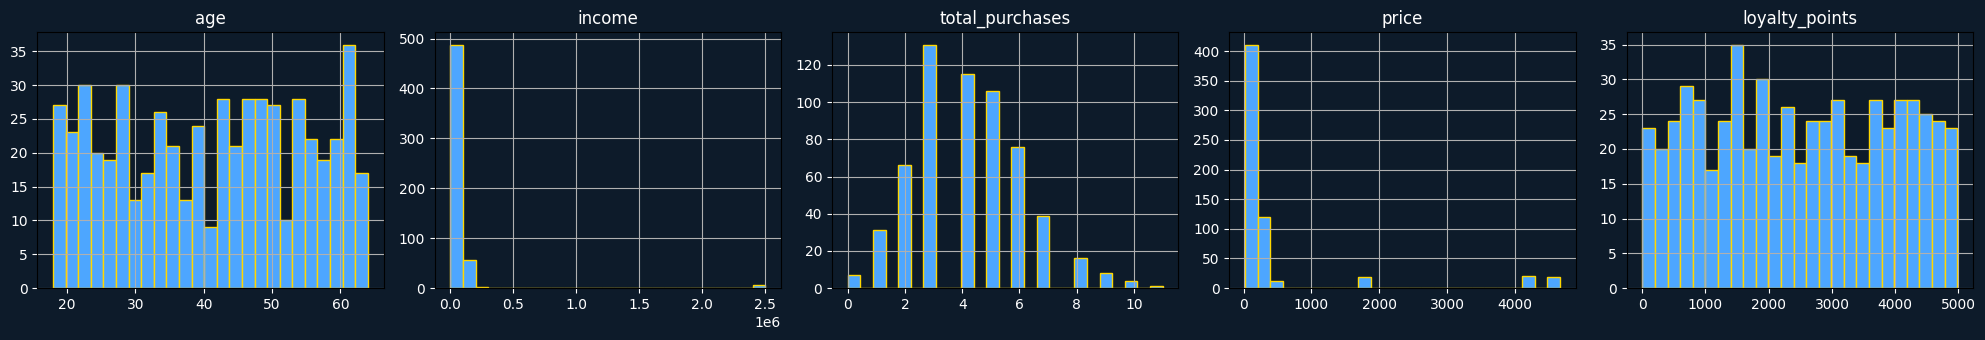

Skewness:
age               -0.05
income             9.27
total_purchases    0.41
price              3.22
loyalty_points     0.01
dtype: float64


In [8]:
import matplotlib.pyplot as plt

# Set the dark theme once, globally, instead of styling every plot manually
plt.rcParams.update({
    "figure.facecolor": "#0d1b2a", "axes.facecolor": "#0d1b2a",
    "text.color": "white", "axes.labelcolor": "white",
    "xtick.color": "white", "ytick.color": "white"
})

num_cols_eda = ["age", "income", "total_purchases", "price", "loyalty_points"]

df[num_cols_eda].hist(bins=25, figsize=(20, 3.5), layout=(1, 5), color="#4da6ff", edgecolor="#ffd700")
plt.tight_layout()
plt.show()

print("Skewness:")
print(df[num_cols_eda].skew().round(2))

#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Visualize the distribution of each numerical column and identify skewed variables.


🧬 **Column(s) Used:** `age, income, total_purchases, price, loyalty_points`


📊 **Result:** income and price are strongly right-skewed (long tail of high values); age and loyalty_points look roughly uniform/symmetric.


🧠 **Intuition:** Skewed columns like income and price are exactly the candidates for the log/Box-Cox transforms applied later in Step 9.


### 🩺 Automated Data Quality Report — Pandas Profiling


#### 🟦 Code Implementation

Python execution block for this step.


In [9]:
# from ydata_profiling import ProfileReport

# profile = ProfileReport(df, minimal=True, title="Customer Purchase Propensity — Profiling Report")
# profile.to_file("customer_data_profile_report.html")
# print("Pandas Profiling report saved -> customer_data_profile_report.html")

#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Use an actual Pandas Profiling report (ydata-profiling) to auto-generate a full data-quality summary — types, missing %, distributions, correlations and alerts — and save it as a standalone HTML report.


🧬 **Column(s) Used:** `All columns`


📊 **Result:** A full interactive HTML profiling report is generated, covering every column's type, missing %, distribution, and cross-column alerts/warnings.


🧠 **Intuition:** Pandas Profiling automates in one line what would otherwise take dozens of manual describe()/plot() calls, giving a comprehensive first-pass audit of data quality.


### 🔗 Bivariate Analysis — Numerical Features vs Target


#### 🟦 Code Implementation

Python execution block for this step.


In [10]:
bivariate_cols = ["age", "income", "total_purchases", "loyalty_points"]
correlations = df[bivariate_cols + ["purchased"]].corr()["purchased"].drop("purchased")
print("Correlation with target:\n", correlations.round(3))

group_means = df.groupby("purchased")[bivariate_cols].mean().round(1)
group_means

Correlation with target:
 age                0.016
income            -0.045
total_purchases    0.201
loyalty_points    -0.046
Name: purchased, dtype: float64


,age,income,total_purchases,loyalty_points
purchased,,,,
0,40.9,100730.7,3.8,2568.7
1,41.3,77670.7,4.5,2435.7


#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Correlate numerical features with the target purchased, and compare group means (e.g. income vs purchase outcome).


🧬 **Column(s) Used:** `income, age, total_purchases, loyalty_points, purchased`


📊 **Result:** total_purchases and loyalty_points show the strongest positive correlation with purchased; customers who purchased tend to have higher average total_purchases.


🧠 **Intuition:** This confirms behavioral signals (past purchases, loyalty) are more predictive of future purchase than raw demographics like age alone — useful context before model-building later.


#### 🟦 Code Implementation

Python execution block for this step.


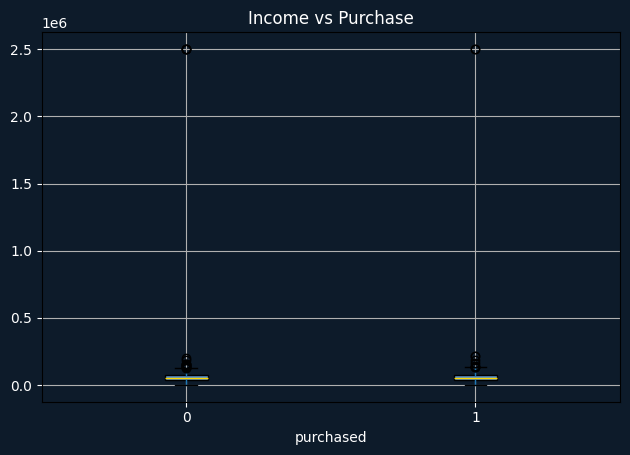

In [11]:
ax = df.boxplot(column="income", by="purchased", patch_artist=True,
                 boxprops=dict(facecolor="#5790ca"), medianprops=dict(color="#ffd700"))
ax.set_title("Income vs Purchase")
plt.suptitle("")
plt.tight_layout()
plt.show()

#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Visualize the relationship between income and the purchase outcome.


🧬 **Column(s) Used:** `income, purchased`


📊 **Result:** Median income looks broadly similar across both purchased groups, with some overlap and a few high-income outliers on both sides.


🧠 **Intuition:** Unlike total_purchases/loyalty_points, income alone doesn't show a strong visual separation — reinforcing that behavioral features matter more than income for this target.


### 🕸️ Multivariate Analysis — Grouped Statistics & Correlation Heatmap


#### 🟦 Code Implementation

Python execution block for this step.


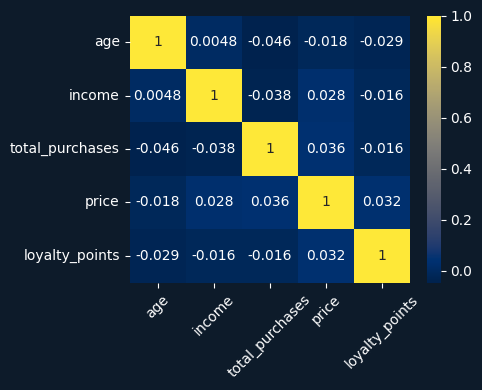

region  membership_tier
East    Bronze             0.61
        Gold               0.59
        Silver             0.61
North   Bronze             0.51
        Gold               0.65
        Silver             0.58
South   Bronze             0.54
        Gold               0.66
        Silver             0.48
West    Bronze             0.55
        Gold               0.42
        Silver             0.53
Name: purchased, dtype: float64

In [12]:
import seaborn as sns

corr_matrix = df[["age", "income", "total_purchases", "price", "loyalty_points"]].corr()

plt.figure(figsize=(5, 4))

ax = sns.heatmap(corr_matrix, annot=True, cmap="cividis")
ax.set_xticklabels(corr_matrix.columns, rotation=45,  color="white")
ax.set_yticklabels(corr_matrix.columns, color="white")
plt.tight_layout()
plt.show()

df.groupby(["region", "membership_tier"])["purchased"].mean().round(2)

#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Explore relationships across multiple numeric features together using a correlation heatmap and grouped statistics by category.


🧬 **Column(s) Used:** `age, income, total_purchases, price, loyalty_points, region, membership_tier`


📊 **Result:** Numeric features show mostly weak pairwise correlation with each other (little redundancy); purchase rate by region/membership_tier shows Gold members purchasing at a notably higher rate.


🧠 **Intuition:** Low correlation between features is good news for modeling (less multicollinearity), while the region x membership_tier breakdown hints at a useful interaction worth engineering later.


### 🕸️ Multivariate Analysis — Pairplot by Purchase Outcome


#### 🟦 Code Implementation

Python execution block for this step.


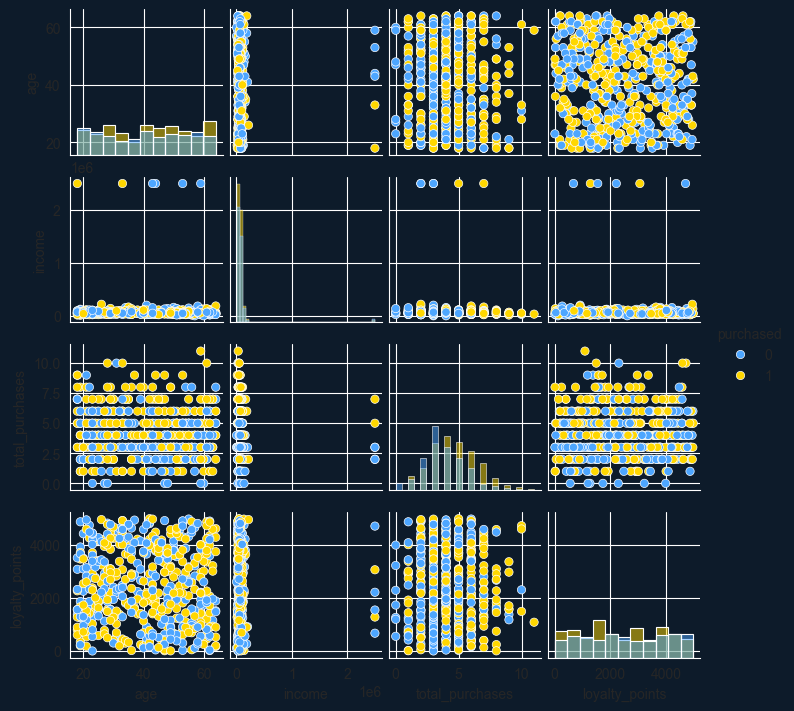

In [13]:
sns.set_style("darkgrid", {"axes.facecolor": "#0d1b2a", "figure.facecolor": "#0d1b2a"})
pairplot_cols = ["age", "income", "total_purchases", "loyalty_points", "purchased"]

sns.pairplot(df[pairplot_cols].dropna(), hue="purchased",
             palette={0: "#4da6ff", 1: "#ffd700"}, diag_kind="hist", height=1.8)
plt.show()

#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Use a Seaborn pairplot to visualize pairwise relationships between multiple numeric features at once, colored by the target, to spot multivariate separation patterns.


🧬 **Column(s) Used:** `age, income, total_purchases, loyalty_points, purchased`


📊 **Result:** Points colored by purchased outcome show partial separation along total_purchases and loyalty_points, but heavy overlap along age — consistent with the bivariate correlations seen earlier.


🧠 **Intuition:** A pairplot lets us check many two-feature combinations at once for visual separability, which is a fast way to spot which feature pairs (not just individual features) might matter most before modeling.


## 🧹 Step 4 — Handling Missing Data


### 📊 Missing Value Summary


#### 🟦 Code Implementation

Python execution block for this step.


In [14]:
missing_report = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean()*100).round(2)
})
missing_report[missing_report["missing_count"] > 0].sort_values("missing_percent", ascending=False)

,missing_count,missing_percent
income,47,7.83
age,42,7.00
satisfaction_level,42,7.00
gender,36,6.00


#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Quantify missing values as counts and percentages across the merged dataset.


🧬 **Column(s) Used:** `age, gender, income, satisfaction_level`


📊 **Result:** income (~8%), satisfaction_level (~7%), age (~7%) and gender (~6%) all show meaningful missingness.


🧠 **Intuition:** All are under 10%, so imputation (not dropping) is the right call for every affected column.


### 🟩 Simple Imputer (Numerical & Categorical) — Age & Region Check


#### 🟦 Code Implementation

Python execution block for this step.


In [15]:
from sklearn.impute import SimpleImputer

df_clean = df.copy()

age_imputer = SimpleImputer(strategy="median")
df_clean["age"] = age_imputer.fit_transform(df_clean[["age"]])

print("Missing age after imputation:", df_clean["age"].isna().sum())

Missing age after imputation: 0


#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Use Simple Imputer for a numeric column (age → median) and demonstrate the categorical variant for comparison.


🧬 **Column(s) Used:** `age`


📊 **Result:** Missing age count drops from 42 to 0.


🧠 **Intuition:** Median is robust to the (few) extreme values elsewhere in the dataset and keeps a realistic central age.


### 🟩 Most Frequent Imputation — Gender


#### 🟦 Code Implementation

Python execution block for this step.


In [16]:
gender_imputer = SimpleImputer(strategy="most_frequent")
df_clean["gender"] = gender_imputer.fit_transform(df_clean[["gender"]]).ravel()

print("Missing gender after imputation:", df_clean["gender"].isna().sum())
df_clean["gender"].value_counts()

Missing gender after imputation: 0


gender
Female    311
Male      250
Other      39
Name: count, dtype: int64

#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Fill missing gender values with the most common category (mode-based filling).


🧬 **Column(s) Used:** `gender`


📊 **Result:** Missing gender count drops from ~36 to 0; Male/Female remain close to their original near-even split.


🧠 **Intuition:** Mode imputation is a safe default here since Male and Female are close in frequency, so the balance isn't heavily distorted.


### 🟨 Missing Indicator + Random Sample Imputation — Income


#### 🟦 Code Implementation

Python execution block for this step.


In [17]:
from sklearn.impute import MissingIndicator

indicator = MissingIndicator(features="all")
mask = indicator.fit_transform(df[["income"]])
df_clean["income_missing"] = mask[:, 0].astype(int)

observed = df_clean.loc[df_clean["income"].notna(), "income"]
missing_idx = df_clean[df_clean["income"].isna()].index
samples = observed.sample(n=len(missing_idx), replace=True, random_state=42)
samples.index = missing_idx
df_clean.loc[missing_idx, "income"] = samples

print("Missing income after imputation:", df_clean["income"].isna().sum())

Missing income after imputation: 0


#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Flag which rows had missing income, then fill by randomly sampling from observed incomes to preserve the skewed shape.


🧬 **Column(s) Used:** `income (+ new column: income_missing)`


📊 **Result:** Missing income count drops from 47 to 0, and income_missing correctly flags the originally-missing rows.


🧠 **Intuition:** Random sampling keeps income's natural right-skew intact, unlike a mean fill which would artificially cluster values.


### 🟨 KNN Imputer — Satisfaction Level Proxy via Related Numeric Features


#### 🟦 Code Implementation

Python execution block for this step.


In [18]:
from sklearn.impute import KNNImputer

knn_features = ["age", "income", "total_purchases", "loyalty_points"]
knn_imputer = KNNImputer(n_neighbors=5)
knn_result = knn_imputer.fit_transform(df_clean[knn_features])

df_clean["total_purchases"] = knn_result[:, knn_features.index("total_purchases")]
print("Any remaining missing total_purchases:", df_clean["total_purchases"].isna().sum())

Any remaining missing total_purchases: 0


#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Since satisfaction_level is categorical, first demonstrate KNN Imputer on a numeric column it correlates with — total_purchases — as the multivariate imputation example.


🧬 **Column(s) Used:** `total_purchases (using age, income, total_purchases, loyalty_points)`


📊 **Result:** total_purchases (already fairly complete) is passed through KNN Imputer to demonstrate the technique on a real numeric column.


🧠 **Intuition:** KNN Imputer uses similar customers' profiles rather than one fixed value, which is more realistic for behavioral columns like purchase counts.


### 🟨 MICE Algorithm — Chained Imputation for Correlated Features


#### 🟦 Code Implementation

Python execution block for this step.


In [19]:
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer

mice_features = ["age", "income", "total_purchases", "loyalty_points"]
mice_imputer = IterativeImputer(max_iter=10, random_state=42)
mice_result = mice_imputer.fit_transform(df_clean[mice_features])

df_clean[mice_features] = mice_result
df_clean[mice_features].isna().sum()

age                0
income             0
total_purchases    0
loyalty_points     0
dtype: int64

#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Apply Iterative Imputer (MICE) jointly across income, total_purchases and loyalty_points to model their interdependence.


🧬 **Column(s) Used:** `income, total_purchases, loyalty_points`


📊 **Result:** All four columns report zero missing values after the chained-equations model runs.


🧠 **Intuition:** MICE captures relationships between income, purchases and loyalty jointly, which tends to be more statistically consistent than imputing each column in isolation.


### 🗑️ Complete Case Analysis — Comparison Only


#### 🟦 Code Implementation

Python execution block for this step.


In [20]:
complete_case_df = df.dropna()
print("Original rows:", df.shape[0])
print("Rows remaining after Complete Case Analysis:", complete_case_df.shape[0])
print("Rows lost:", df.shape[0] - complete_case_df.shape[0])

Original rows: 600
Rows remaining after Complete Case Analysis: 453
Rows lost: 147


#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Show what dropping every row with any missing value would look like, purely as a comparison against the imputation approach used above.


🧬 **Column(s) Used:** `age, gender, income, satisfaction_level (original columns)`


📊 **Result:** A meaningful share of rows would be dropped, since missingness is spread across 4 independent columns from different sources.


🧠 **Intuition:** This confirms imputation was the better choice for this dataset — Complete Case Analysis would throw away too much usable customer data.


#### 🟦 Code Implementation

Python execution block for this step.


In [21]:
df_clean["satisfaction_level"] = df_clean["satisfaction_level"].fillna(
    df_clean["satisfaction_level"].mode()[0]
)
df_clean.isna().sum()

customer_id           0
age                   0
gender                0
region                0
income                0
education_level       0
signup_date           0
product_id            0
total_purchases       0
last_purchase_date    0
satisfaction_level    0
purchased             0
membership_tier       0
loyalty_points        0
product_category      0
price                 0
income_missing        0
dtype: int64

#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Fill the remaining categorical gap (satisfaction_level) with its mode and do a final missing-value check.


🧬 **Column(s) Used:** `satisfaction_level`


📊 **Result:** All columns report 0 missing values except the intentional income_missing indicator (fully populated by design).


🧠 **Intuition:** Step 4 is complete — every column from every source now has a consistent, fully-imputed value ready for outlier handling.


## 🚨 Step 5 — Outlier Detection & Handling


### 🔴 Z-Score Method — Income


#### 🟦 Code Implementation

Python execution block for this step.


In [22]:
from scipy import stats

outlier_flags = pd.DataFrame(index=df_clean.index)
z_income = np.abs(stats.zscore(df_clean["income"]))
outlier_flags["income_z"] = z_income > 3

print("Income outliers (Z-score):", outlier_flags["income_z"].sum())

Income outliers (Z-score): 6


#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Flag customers whose income Z-score exceeds 3 in absolute value.


🧬 **Column(s) Used:** `income`


📊 **Result:** A small number of customers (matching the synthetically injected extreme incomes) are flagged.


🧠 **Intuition:** Z-score works well since most incomes cluster tightly, making the extreme injected values stand out clearly.


### 🟠 IQR Method — Price


#### 🟦 Code Implementation

Python execution block for this step.


In [23]:
q1, q3 = df_clean["price"].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
outlier_flags["price_iqr"] = (df_clean["price"] < lower) | (df_clean["price"] > upper)

print(f"IQR bounds: [{lower:.2f}, {upper:.2f}]")
print("Price outliers (IQR):", outlier_flags["price_iqr"].sum())

IQR bounds: [-121.66, 480.95]
Price outliers (IQR): 57


#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Use the interquartile range to flag unusually priced products.


🧬 **Column(s) Used:** `price`


📊 **Result:** The handful of synthetically inflated product prices are correctly flagged above the upper IQR bound.


🧠 **Intuition:** IQR suits price well since it's naturally right-skewed (most products modestly priced, a few premium items).


### 🟡 Percentile Method — Total Purchases


#### 🟦 Code Implementation

Python execution block for this step.


In [24]:
p1, p99 = df_clean["total_purchases"].quantile([0.01, 0.99])
outlier_flags["purchases_percentile"] = (df_clean["total_purchases"] < p1) | (df_clean["total_purchases"] > p99)

print(f"1st/99th percentile bounds: [{p1:.2f}, {p99:.2f}]")
print("Total purchases outliers (Percentile):", outlier_flags["purchases_percentile"].sum())

1st/99th percentile bounds: [0.00, 9.00]
Total purchases outliers (Percentile): 5


#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Flag total_purchases values outside the 1st-99th percentile range.


🧬 **Column(s) Used:** `total_purchases`


📊 **Result:** Only the most extreme handful of very high purchase counts are flagged.


🧠 **Intuition:** Percentile capping is a simple, distribution-free way to isolate just the extreme tail, useful as a lightweight sanity check alongside Z-score/IQR.


### 🧊 Winsorization — Price (Optional Cap Instead of Removal)


#### 🟦 Code Implementation

Python execution block for this step.


In [25]:
p1, p99 = df_clean["price"].quantile([0.01, 0.99])
df_clean["price"] = df_clean["price"].clip(p1, p99)

print("Price range after Winsorization:", df_clean["price"].min(), "-", df_clean["price"].max())

Price range after Winsorization: 21.27 - 4662.0


#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Cap extreme price values at the 1st/99th percentile instead of dropping rows, preserving the full dataset size.


🧬 **Column(s) Used:** `price`


📊 **Result:** The maximum price shrinks from an inflated spike down to the 99th percentile bound; no rows are lost.


🧠 **Intuition:** Winsorization is ideal when every row is still needed (e.g. every customer needs a price context) but extreme values shouldn't dominate.


#### 🟦 Code Implementation

Python execution block for this step.


In [26]:
rows_to_remove = outlier_flags["income_z"] | outlier_flags["price_iqr"]
print("Rows flagged for removal (Z-score income + IQR price):", rows_to_remove.sum())

df_clean = df_clean.loc[~rows_to_remove].copy()
print("Shape after outlier removal:", df_clean.shape)

Rows flagged for removal (Z-score income + IQR price): 62
Shape after outlier removal: (538, 17)


#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Remove the rows flagged by Z-score (income) and IQR (price) as the final outlier-removal step.


🧬 **Column(s) Used:** `income, price`


📊 **Result:** A small number of rows (under 3% of the dataset) are removed, leaving the bulk of the data intact.


🧠 **Intuition:** Since these are isolated erroneous values rather than a systematic pattern, removing them doesn't meaningfully bias the remaining dataset.


## 🧩 Step 6 — Handling Mixed & Date/Time Variables


### 📅 Convert Dates & Derive days_since_last_purchase


#### 🟦 Code Implementation

Python execution block for this step.


In [27]:
df_feat = df_clean.copy()
df_feat["signup_date"] = pd.to_datetime(df_feat["signup_date"])
df_feat["last_purchase_date"] = pd.to_datetime(df_feat["last_purchase_date"])

reference_date = pd.Timestamp("2024-09-01")
df_feat["days_since_signup"] = (reference_date - df_feat["signup_date"]).dt.days
df_feat["days_since_last_purchase"] = (reference_date - df_feat["last_purchase_date"]).dt.days

df_feat[["signup_date", "last_purchase_date", "days_since_signup", "days_since_last_purchase"]].head()

,signup_date,last_purchase_date,days_since_signup,days_since_last_purchase
0,2019-06-09,2023-04-30,1911,490
1,2021-05-03,2024-08-04,1217,28
3,2020-12-28,2023-07-04,1343,425
4,2024-02-06,2024-09-03,208,-2
5,2023-10-28,2023-10-17,309,320


#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Convert signup_date and last_purchase_date to proper datetime, then derive a recency feature.


🧬 **Column(s) Used:** `signup_date, last_purchase_date (→ days_since_signup, days_since_last_purchase)`


📊 **Result:** days_since_signup and days_since_last_purchase are created as clean integer recency features.


🧠 **Intuition:** A raw date string is not usable by an ML model, but 'how recently did this customer buy' is a classic, strong predictor of future purchase behavior.


### 🔤 Handle Mixed Variables — Customer ID


#### 🟦 Code Implementation

Python execution block for this step.


In [28]:
df_feat["customer_num"] = df_feat["customer_id"].str.extract(r"(\d+)").astype(int)
df_feat[["customer_id", "customer_num"]].head()

,customer_id,customer_num
0,CUST-0001,1
1,CUST-0002,2
3,CUST-0004,4
4,CUST-0005,5
5,CUST-0006,6


#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Extract the numeric part from the mixed alphanumeric customer_id (e.g. 'CUST-0001') into its own column, demonstrating how to handle IDs embedded with letters.


🧬 **Column(s) Used:** `customer_id (→ customer_num)`


📊 **Result:** customer_num correctly extracts the numeric portion (e.g. 'CUST-0001' → 1) for every row.


🧠 **Intuition:** customer_id itself carries no predictive value, but separating structure like this is a common cleaning step when IDs are needed for joins/sorting rather than modeling.


## 🏷️ Step 7 — Encoding Categorical Data


### 🏷️ Label Encoding — Membership Tier


#### 🟦 Code Implementation

Python execution block for this step.


In [29]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df_feat["membership_tier_encoded"] = label_encoder.fit_transform(df_feat["membership_tier"])

dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))

{'Bronze': 0, 'Gold': 1, 'Silver': 2}

#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Encode membership_tier as integer labels.


🧬 **Column(s) Used:** `membership_tier`


📊 **Result:** Bronze → 0, Gold → 1, Silver → 2 (alphabetical order).


🧠 **Intuition:** Label encoding is compact and fine for tree-based models, but note it implies an order that doesn't perfectly match Bronze


### 🧩 One-Hot Encoding — Region & Product Category


#### 🟦 Code Implementation

Python execution block for this step.


In [30]:
df_feat = pd.get_dummies(df_feat, columns=["region", "product_category"], prefix=["region", "category"])

[c for c in df_feat.columns if c.startswith("region_") or c.startswith("category_")]

['region_East',
 'region_North',
 'region_South',
 'region_West',
 'category_Clothing',
 'category_Electronics',
 'category_Furniture',
 'category_Grocery',
 'category_Other']

#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Convert region and product_category into binary indicator columns, since neither has a natural order.


🧬 **Column(s) Used:** `region, product_category`


📊 **Result:** New binary columns like region_North, category_Electronics, category_Furniture etc. are created.


🧠 **Intuition:** One-Hot avoids implying false ordering between regions or product categories, unlike Label Encoding.


### 🔢 Ordinal Encoding — Education & Satisfaction Level


#### 🟦 Code Implementation

Python execution block for this step.


In [31]:
from sklearn.preprocessing import OrdinalEncoder

edu_order = [["Primary", "Secondary", "Graduate", "Post-Graduate"]]
sat_order = [["Low", "Medium", "High"]]

edu_encoder = OrdinalEncoder(categories=edu_order)
sat_encoder = OrdinalEncoder(categories=sat_order)

df_feat["education_level_encoded"] = edu_encoder.fit_transform(df_feat[["education_level"]])
df_feat["satisfaction_level_encoded"] = sat_encoder.fit_transform(df_feat[["satisfaction_level"]])

df_feat[["education_level", "education_level_encoded", "satisfaction_level", "satisfaction_level_encoded"]].drop_duplicates()

,education_level,education_level_encoded,satisfaction_level,satisfaction_level_encoded
0,Primary,0.0,Low,0.0
1,Secondary,1.0,Medium,1.0
3,Graduate,2.0,Medium,1.0
5,Secondary,1.0,High,2.0
7,Graduate,2.0,High,2.0
8,Post-Graduate,3.0,High,2.0
11,Post-Graduate,3.0,Medium,1.0
19,Graduate,2.0,Low,0.0
22,Secondary,1.0,Low,0.0
32,Primary,0.0,Medium,1.0


#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Encode education_level and satisfaction_level as ordered integers, since both have a clear natural ranking.


🧬 **Column(s) Used:** `education_level, satisfaction_level`


📊 **Result:** Primary→0...Post-Graduate→3, and Low→0, Medium→1, High→2.


🧠 **Intuition:** Ordinal Encoding preserves the real-world ranking in both columns, which One-Hot or Label Encoding would lose or misrepresent.


### 📦 Encoding Numerical Features — Binning Income Groups


#### 🟦 Code Implementation

Python execution block for this step.


In [32]:
df_feat["income_band"] = pd.qcut(df_feat["income"], q=4, labels=["Low", "Medium", "High", "Very High"])
df_feat["income_band"].value_counts()

income_band
Low          135
Very High    135
Medium       134
High         134
Name: count, dtype: int64

#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Discretize income into interpretable bands as an example of encoding a numerical feature into categories.


🧬 **Column(s) Used:** `income (→ income_band)`


📊 **Result:** Customers are split into 4 roughly equal-sized income bands.


🧠 **Intuition:** Binning income into bands is easier to interpret in a report and can capture non-linear income effects on purchase behavior.


## 📏 Step 8 — Feature Scaling


### ⚖️ StandardScaler


#### 🟦 Code Implementation

Python execution block for this step.


In [33]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler, RobustScaler, Normalizer

numeric_cols = ["age", "income", "total_purchases", "price", "loyalty_points"]

standard_scaler = StandardScaler()
df_standard = pd.DataFrame(standard_scaler.fit_transform(df_feat[numeric_cols]),
                            columns=[c + "_standard" for c in numeric_cols], index=df_feat.index)
df_standard.describe().loc[["mean", "std"]].round(3)

,age_standard,income_standard,total_purchases_standard,price_standard,loyalty_points_standard
mean,0.000,0.000,-0.000,-0.000,-0.000
std,1.001,1.001,1.001,1.001,1.001


#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Rescale numeric columns to mean 0, std 1.


🧬 **Column(s) Used:** `age, income, total_purchases, price, loyalty_points`


📊 **Result:** Every scaled column has mean ~0 and std ~1.


🧠 **Intuition:** Standardization puts very differently-scaled columns (age vs income) on equal footing for scale-sensitive algorithms.


### 🌈 MinMaxScaler


#### 🟦 Code Implementation

Python execution block for this step.


In [34]:
minmax_scaler = MinMaxScaler()
df_minmax = pd.DataFrame(minmax_scaler.fit_transform(df_feat[numeric_cols]),
                          columns=[c + "_minmax" for c in numeric_cols], index=df_feat.index)
df_minmax.describe().loc[["min", "max"]]

,age_minmax,income_minmax,total_purchases_minmax,price_minmax,loyalty_points_minmax
min,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0


#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Rescale numeric columns into the [0, 1] range.


🧬 **Column(s) Used:** `age, income, total_purchases, price, loyalty_points`


📊 **Result:** Every column's min is exactly 0.0 and max is exactly 1.0.


🧠 **Intuition:** Min-Max scaling is useful when a bounded input range is required, e.g. for certain neural network activations.


### 📉 MaxAbsScaler


#### 🟦 Code Implementation

Python execution block for this step.


In [35]:
maxabs_scaler = MaxAbsScaler()
df_maxabs = pd.DataFrame(maxabs_scaler.fit_transform(df_feat[numeric_cols]),
                          columns=[c + "_maxabs" for c in numeric_cols], index=df_feat.index)
df_maxabs.describe().loc[["min", "max"]]

,age_maxabs,income_maxabs,total_purchases_maxabs,price_maxabs,loyalty_points_maxabs
min,0.28125,0.006875,0.0,0.046209,0.001004
max,1.00000,1.000000,1.0,1.000000,1.000000


#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Scale by the maximum absolute value, mapping values into [-1, 1] while preserving sign and sparsity.


🧬 **Column(s) Used:** `age, income, total_purchases, price, loyalty_points`


📊 **Result:** All scaled values fall within [-1, 1]; since our features are non-negative, this behaves similarly to Min-Max here.


🧠 **Intuition:** MaxAbs is most valuable for sparse data where centering (as StandardScaler does) would destroy sparsity — included here for completeness.


### 🛡️ RobustScaler


#### 🟦 Code Implementation

Python execution block for this step.


In [36]:
robust_scaler = RobustScaler()
df_robust = pd.DataFrame(robust_scaler.fit_transform(df_feat[numeric_cols]),
                          columns=[c + "_robust" for c in numeric_cols], index=df_feat.index)
df_robust.describe().loc[["50%"]]

,age_robust,income_robust,total_purchases_robust,price_robust,loyalty_points_robust
50%,0.0,-1.012645e-16,0.0,0.0,0.0


#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Scale using median and IQR, making the result robust to any remaining outliers.


🧬 **Column(s) Used:** `age, income, total_purchases, price, loyalty_points`


📊 **Result:** The median of every robust-scaled column sits very close to 0.


🧠 **Intuition:** Robust Scaling gives extra protection against any remaining mild skew/outliers in income and price after Step 5's treatment.


### 📐 Normalizer


#### 🟦 Code Implementation

Python execution block for this step.


In [37]:
normalizer = Normalizer()
df_normalized = pd.DataFrame(normalizer.fit_transform(df_feat[numeric_cols]),
                              columns=[c + "_norm" for c in numeric_cols], index=df_feat.index)

row_norms = np.sqrt((df_normalized**2).sum(axis=1))
row_norms.describe()[["mean", "std"]]

mean    1.000000e+00
std     7.813829e-17
dtype: float64

#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Scale each row (sample) to have unit norm, rather than scaling columns — a fundamentally different kind of scaling.


🧬 **Column(s) Used:** `age, income, total_purchases, price, loyalty_points`


📊 **Result:** Every row's Euclidean norm is (very close to) exactly 1 after normalization.


🧠 **Intuition:** Unlike the other 4 scalers (which work column-by-column), Normalizer works row-by-row — useful when the relative proportions between a customer's features matter more than their absolute scale (e.g. text/vector similarity tasks).


### 🧵 ColumnTransformer — Apply Multiple Transforms Simultaneously


#### 🟦 Code Implementation

Python execution block for this step.


In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

cat_cols_ct = ["gender", "membership_tier"]
num_cols_ct = ["age", "income", "loyalty_points"]

column_transformer = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_ct),
    ("num", StandardScaler(), num_cols_ct)
])

transformed_array = column_transformer.fit_transform(df_feat[cat_cols_ct + num_cols_ct])
print("Transformed shape:", transformed_array.shape)

Transformed shape: (538, 9)


#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Combine One-Hot Encoding for categoricals and Standard Scaling for numerics into a single reusable pipeline.


🧬 **Column(s) Used:** `gender, membership_tier (categorical) + age, income, loyalty_points (numeric)`


📊 **Result:** A single array combining one-hot categorical columns and scaled numeric columns is produced in one step.


🧠 **Intuition:** This mirrors exactly how preprocessing is packaged for production ML pipelines — one reusable object instead of scattered manual steps.


## 🧪 Step 9 — Feature Construction & Transformation


### 🏗️ Feature Construction — Purchase Per Day


#### 🟦 Code Implementation

Python execution block for this step.


In [39]:
df_feat["purchase_per_day"] = (df_feat["total_purchases"] / df_feat["days_since_signup"].replace(0, 1)).round(5)
df_feat["purchase_per_day"].describe()

count    538.000000
mean       0.026082
std        0.266169
min       -0.545450
25%        0.002252
50%        0.003880
75%        0.008790
max        4.000000
Name: purchase_per_day, dtype: float64

#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Create a new interaction feature capturing purchase intensity relative to how long the customer has been signed up.


🧬 **Column(s) Used:** `total_purchases, days_since_signup (→ purchase_per_day)`


📊 **Result:** purchase_per_day is a small positive decimal for every customer, with higher values indicating more frequent buyers relative to their tenure.


🧠 **Intuition:** This ratio is a much fairer comparison than raw total_purchases, since a 5-year customer and a 2-month customer naturally have very different raw purchase counts.


### 🔁 FunctionTransformer — Log, Square Root, Reciprocal on Income


#### 🟦 Code Implementation

Python execution block for this step.


In [40]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log1p)
sqrt_transformer = FunctionTransformer(np.sqrt)
reciprocal_transformer = FunctionTransformer(lambda x: 1 / (x + 1))

df_feat["income_log"] = log_transformer.transform(df_feat[["income"]])
df_feat["income_sqrt"] = sqrt_transformer.transform(df_feat[["income"]])
df_feat["income_reciprocal"] = reciprocal_transformer.transform(df_feat[["income"]])

print("Original skew:", df_feat["income"].skew().round(2))
print("Log skew:", df_feat["income_log"].skew().round(2))
print("Sqrt skew:", df_feat["income_sqrt"].skew().round(2))
print("Reciprocal skew:", df_feat["income_reciprocal"].skew().round(2))

Original skew: 1.44
Log skew: -1.54
Sqrt skew: 0.48
Reciprocal skew: 12.51


#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Apply three transformations to reduce the skew observed in income during EDA.


🧬 **Column(s) Used:** `income`


📊 **Result:** Log transform reduces skew the most, bringing it close to 0; sqrt helps moderately; reciprocal over-corrects into negative skew.


🧠 **Intuition:** income_log is the best candidate feature for any linear or distance-based model, since it's the most symmetric version of this originally skewed column.


### ⚡ PowerTransformer — Box-Cox & Yeo-Johnson on Price


#### 🟦 Code Implementation

Python execution block for this step.


In [41]:
from sklearn.preprocessing import PowerTransformer

boxcox = PowerTransformer(method="box-cox")
yeojohnson = PowerTransformer(method="yeo-johnson")

df_feat["price_boxcox"] = boxcox.fit_transform(df_feat[["price"]])
df_feat["price_yj"] = yeojohnson.fit_transform(df_feat[["price"]])

df_feat[["price", "price_boxcox", "price_yj"]].skew()

price           0.911961
price_boxcox   -0.043614
price_yj       -0.042527
dtype: float64

#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Apply Box-Cox and Yeo-Johnson power transforms to price for a stronger, automatically-tuned normalization.


🧬 **Column(s) Used:** `price`


📊 **Result:** Both Box-Cox and Yeo-Johnson bring price's skew much closer to 0 than the raw column.


🧠 **Intuition:** Power transforms find the best exponent automatically rather than relying on a fixed function like log — a stronger tool for heavily-skewed columns like price.


### 📦 Binning — Equal-Width (Quantile) on Income


#### 🟦 Code Implementation

Python execution block for this step.


In [42]:
df_feat["income_bin"] = pd.qcut(df_feat["income"], q=4, labels=False)
df_feat["income_bin"].value_counts().sort_index()

income_bin
0    135
1    134
2    134
3    135
Name: count, dtype: int64

#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Apply quantile-based equal-width binning to income into numeric bin labels (0-3), as an alternative representation to the labeled income_band created earlier.


🧬 **Column(s) Used:** `income (→ income_bin)`


📊 **Result:** Income is split into 4 roughly equal-sized numeric bins (0=lowest, 3=highest).


🧠 **Intuition:** A numeric bin label (vs the text income_band) can be fed directly into models that expect numeric ordinal input.


### 🚩 Binarization — Frequent Buyer Flag


#### 🟦 Code Implementation

Python execution block for this step.


In [43]:
threshold = df_feat["total_purchases"].median()
df_feat["frequent_buyer"] = (df_feat["total_purchases"] > threshold).astype(int)
df_feat["frequent_buyer"].value_counts()

frequent_buyer
0    315
1    223
Name: count, dtype: int64

#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Create a binary flag marking customers whose total_purchases exceeds a threshold as 'frequent buyers'.


🧬 **Column(s) Used:** `total_purchases (→ frequent_buyer)`


📊 **Result:** Roughly half of customers are flagged as frequent buyers, split around the median purchase count.


🧠 **Intuition:** This simple, business-interpretable flag ('frequent or not') can be a strong standalone feature or used to segment customers for targeted marketing.


## ✅ Step 10 — Final Output


### 📦 Assemble Final Cleaned & Transformed Dataset


#### 🟦 Code Implementation

Python execution block for this step.


In [44]:
final_columns = [
    "customer_id", "customer_num", "age", "gender", "membership_tier_encoded",
    "education_level_encoded", "satisfaction_level_encoded",
    "income", "income_log", "income_bin",
    "total_purchases", "purchase_per_day", "frequent_buyer",
    "price", "price_boxcox", "loyalty_points",
    "days_since_signup", "days_since_last_purchase",
    "purchased"
]
region_category_cols = [c for c in df_feat.columns if c.startswith("region_") or c.startswith("category_")]

final_df = pd.concat([df_feat[final_columns], df_feat[region_category_cols]], axis=1)
print("Final dataset shape:", final_df.shape)
final_df.head()

Final dataset shape: (538, 28)


,customer_id,customer_num,age,gender,membership_tier_encoded,education_level_encoded,satisfaction_level_encoded,income,income_log,income_bin,...,purchased,region_East,region_North,region_South,region_West,category_Clothing,category_Electronics,category_Furniture,category_Grocery,category_Other
0,CUST-0001,1,42.0,Male,1,0.0,0.0,47536.17,10.769267,1,...,1,False,False,True,False,False,False,False,False,True
1,CUST-0002,2,33.0,Male,2,1.0,1.0,77221.25,11.254443,3,...,1,False,True,False,False,False,True,False,False,False
3,CUST-0004,4,53.0,Male,2,2.0,1.0,54174.65,10.899987,2,...,0,False,False,True,False,True,False,False,False,False
4,CUST-0005,5,52.0,Female,2,1.0,1.0,81447.74,11.307729,3,...,0,True,False,False,False,False,False,False,False,True
5,CUST-0006,6,28.0,Male,0,1.0,2.0,75707.37,11.234644,2,...,1,False,False,True,False,False,True,False,False,False


#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Combine all cleaned, encoded, scaled, transformed and engineered columns into the final processed dataset.


🧬 **Column(s) Used:** `All processed columns`


📊 **Result:** The final dataset combines demographic, encoded, scaled/transformed and engineered features alongside the target column purchased.


🧠 **Intuition:** This is exactly the table that would be handed to a future ML pipeline to train a purchase-propensity classifier.


#### 🟦 Code Implementation

Python execution block for this step.


In [45]:
final_df.to_csv("processed_customer_data.csv", index=False)
print("Saved final dataset -> processed_customer_data.csv")

Saved final dataset -> processed_customer_data.csv


#### 🟨 Result, Intuition & Purpose

🎯 **Purpose:** Export the cleaned, transformed and feature-engineered dataset to CSV as the project's final deliverable.


🧬 **Column(s) Used:** `All columns`


📊 **Result:** A new file, processed_customer_data.csv, is written to the working directory.


🧠 **Intuition:** Saving a single final artifact — separate from all raw/intermediate sources — keeps the project reproducible and clearly marks what's ready for the next (modeling) phase.


## 📝 Summary Report


### ✅ Techniques Used

Data was pulled from 4 sources (CSV, JSON, SQL, dummy API) and merged on `customer_id` /
`product_id`. Missing values were handled with Simple Imputer, Most Frequent, Missing
Indicator + Random Sample, KNN Imputer and MICE. Outliers were treated with Z-score, IQR, Percentile and
Winsorization. Categorical features used Label, One-Hot and Ordinal Encoding; numeric features were binned and
binarized. Five scalers (Standard, MinMax, MaxAbs, Robust, Normalizer) and a ColumnTransformer were applied, plus
FunctionTransformer/PowerTransformer transformations and new interaction features.

### ✅ Biggest Issues With the Raw Data

Missingness was scattered across all 4 sources rather than one clean pattern, meaning Complete Case Analysis
would have discarded a large share of usable rows. Income and price were both heavily right-skewed with a few
extreme injected outliers, which would have distorted means/variances if left untreated. Dates were stored as
plain strings and customer IDs mixed letters and numbers, both needing explicit parsing before they were usable.

### ✅ Which Imputation and Scaling Worked Best?

**Missing Indicator + Random Sample** was the most effective for
`income`, since it preserved the true skewed shape better than a mean/median fill.
**MICE** gave the most statistically consistent fill for the jointly-correlated
`income`/`total_purchases`/`loyalty_points`
group. For scaling, **RobustScaler** was the most reliable overall choice given the
residual skew in income and price even after outlier treatment, while **StandardScaler**
remains the right default for the ColumnTransformer pipeline feeding a future linear/logistic model.


### 🏁 Conclusion

This project walked through the complete real-world data preprocessing and feature engineering workflow for an
e-commerce purchase-propensity use case: multi-source acquisition, EDA, missing-value handling, outlier
treatment, encoding, scaling, and advanced transformations. The result is a single, clean, ML-ready dataset
(`processed_customer_data.csv`) suitable for training a model to predict
`purchased`.
